# Read the output of generateZWP.

## The output data are not smoothed so most of the information from the 1D correlation can be retained. Smoothing can be applied here and parameters can be varied to generate the best fit for the final profile.

### The .npz files contain ['wind_prof_raw', 'date_list', 'delta_t_arr', 'crit_lat'].

In [10]:
import planetmapper
import matplotlib
# matplotlib.use('Qt5Agg')
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import datetime
import csv
import os
import glob
import pandas as pd

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class

print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [8]:
long_res, lat_res = 360, 180
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
R_J = 71492e3 # m
R_J_p = 66854e3 # m

def getSmoothedProfile(unsmooth_1D, window_len, poly_order):
    # apply the Savitzky-Golay filter to the final 1D profile
    return sp.signal.savgol_filter(unsmooth_1D, window_len, poly_order)

In [3]:
output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/'
output_file_list = glob.glob(output_path + '*.npz')

for f in output_file_list:
    print(f)

/Users/ahyder/Desktop/windfieldproject/spex/outputs/oct_jc505516_jc057087.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/aug_jc649676_jc042065.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/aug_jc815843_jc148182.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/aug_jc523554_jc042065.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/oct_jc451486_jc057087.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/feb_jc587611_jc187221.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/aug_jc649676_jc148182.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/aug_jc183201_jc148182.npz


In [4]:
corr1D_list = []
date_list = []
delta_t_list = []
crit_lat_list = []
pair_name_list = []

for f in output_file_list:
    npzfile = np.load(f)
    corr1D_list.append(npzfile['wind_prof_raw'])
    date_list.append(npzfile['date_list'])
    delta_t_list.append(npzfile['delta_t_arr'])
    crit_lat_list.append(npzfile['crit_lat'])
    pair_name_list.append(npzfile['pair_names'])

    print(npzfile['date_list'], npzfile['delta_t_arr'])

print()
# comment out if you want to include everything:
index_to_exclude = -3 # feb image jc187221 had a lot of shaking, so this will exclude it from the final ZWP
print('Excluding: ', date_list[index_to_exclude], delta_t_list[index_to_exclude])
del corr1D_list[index_to_exclude]
del date_list[index_to_exclude]
del delta_t_list[index_to_exclude]
del crit_lat_list[index_to_exclude]
del pair_name_list[index_to_exclude]



['2024-10-22T14:01:56.875' '2024-10-23T10:33:15.97266'] [73879.]
['2024-08-16T18:39:46.61719' '2024-08-17T14:45:15.22656'] [72328.]
['2024-08-16T19:50:08.63281' '2024-08-17T15:12:28.84375'] [69740.]
['2024-08-16T18:13:34.26562' '2024-08-17T14:45:15.22656'] [73901.]
['2024-10-22T13:53:25.375' '2024-10-23T10:33:15.97266'] [74391.]
['2024-02-05T03:53:37.46973' '2024-02-06T00:09:08.07947'] [72931.]
['2024-08-16T18:39:46.61719' '2024-08-17T15:12:28.84375'] [73962.]
['2024-08-16T19:50:05.20312' '2024-08-17T15:12:28.84375'] [69744.]

Excluding:  ['2024-02-05T03:53:37.46973' '2024-02-06T00:09:08.07947'] [72931.]


In [5]:
index_to_exclude = 2 
print('Excluding: ', date_list[index_to_exclude], delta_t_list[index_to_exclude])
del corr1D_list[index_to_exclude]
del date_list[index_to_exclude]
del delta_t_list[index_to_exclude]
del crit_lat_list[index_to_exclude]
del pair_name_list[index_to_exclude]

index_to_exclude = -1 
print('Excluding: ', date_list[index_to_exclude], delta_t_list[index_to_exclude])
del corr1D_list[index_to_exclude]
del date_list[index_to_exclude]
del delta_t_list[index_to_exclude]
del crit_lat_list[index_to_exclude]
del pair_name_list[index_to_exclude]

Excluding:  ['2024-08-16T19:50:08.63281' '2024-08-17T15:12:28.84375'] [69740.]
Excluding:  ['2024-08-16T19:50:05.20312' '2024-08-17T15:12:28.84375'] [69744.]


In [6]:
for f in range(len(corr1D_list)):
    print(pair_name_list[f], date_list[f], delta_t_list[f])

['jc505516.fits.gz' 'jc057087.fits.gz'] ['2024-10-22T14:01:56.875' '2024-10-23T10:33:15.97266'] [73879.]
['jc649676.fits.gz' 'jc042065.fits.gz'] ['2024-08-16T18:39:46.61719' '2024-08-17T14:45:15.22656'] [72328.]
['jc523554.fits.gz' 'jc042065.fits.gz'] ['2024-08-16T18:13:34.26562' '2024-08-17T14:45:15.22656'] [73901.]
['jc451486.fits.gz' 'jc057087.fits.gz'] ['2024-10-22T13:53:25.375' '2024-10-23T10:33:15.97266'] [74391.]
['jc649676.fits.gz' 'jc148182.fits.gz'] ['2024-08-16T18:39:46.61719' '2024-08-17T15:12:28.84375'] [73962.]


In [7]:
corr1D_list = np.asarray(corr1D_list)
corr1D_array_smoothed = np.zeros(corr1D_list[:, 0, :].shape)

for i in range(len(corr1D_list)):
    corr1D_array_smoothed[i, :] = getSmoothedProfile(corr1D_list[i, 0, :], 7, 2)

mean_2024_ZWP = np.mean(corr1D_array_smoothed, axis=0)
std_2024_ZWP = np.std(corr1D_array_smoothed, axis=0)

print(corr1D_list[:, 0, :].shape)
print(corr1D_array_smoothed.shape)

(5, 180)
(5, 180)


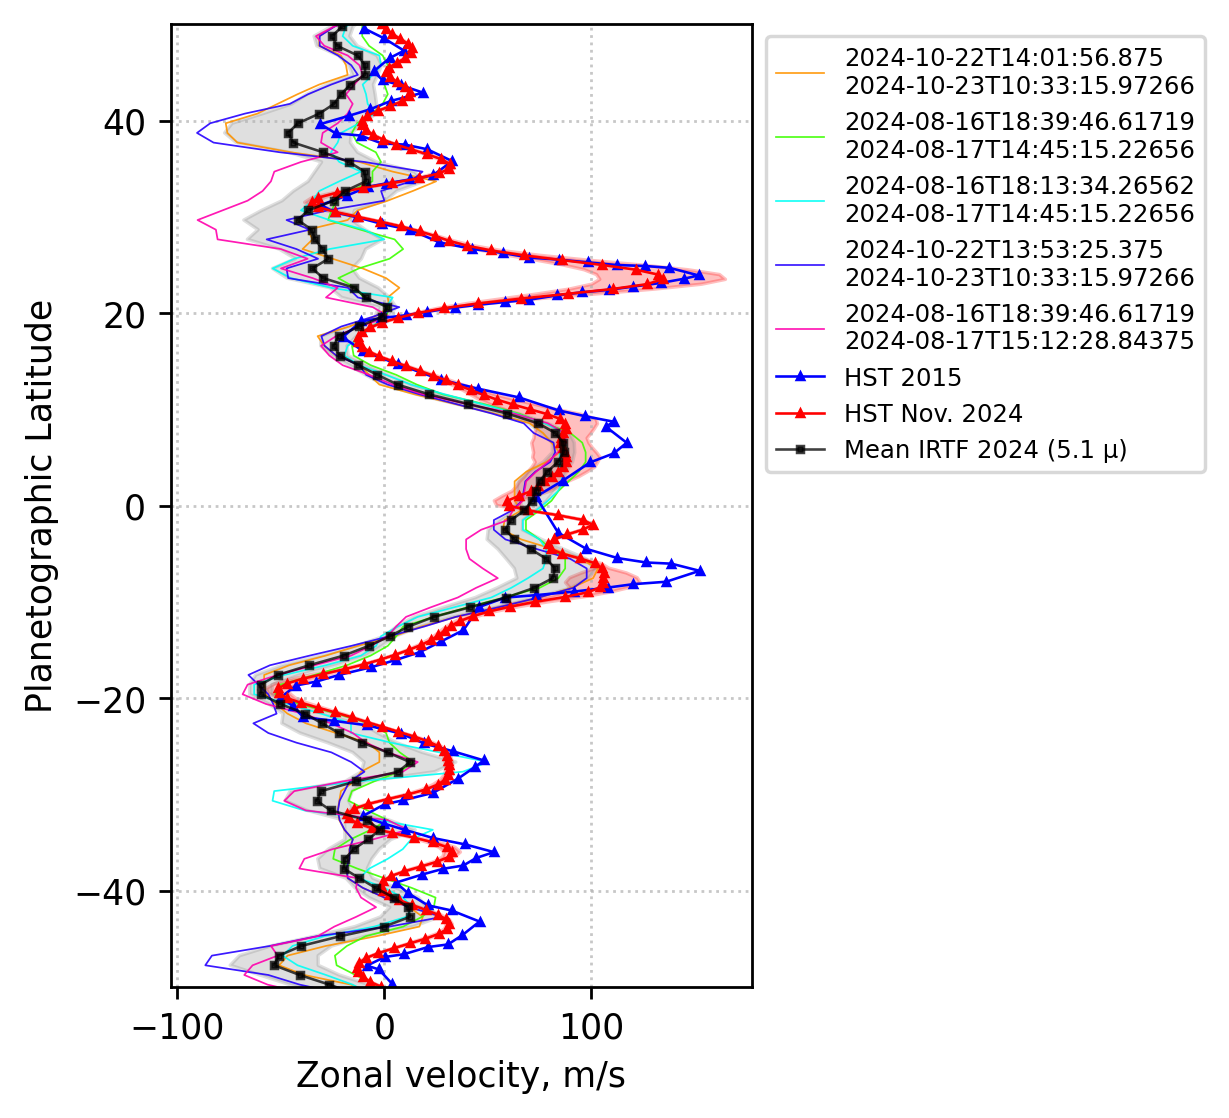

In [16]:

hst_wind_1D = np.genfromtxt('Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)
# opal_nov_2024 = np.genfromtxt('OPAL/2024nov_jup_502.xlsx', delimiter=",", dtype=None, encoding=None, names=True)
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')
opal_nov_2024_error_mag = opal_nov_2024_df['FMZW']*opal_nov_2024_df['ERROR']/100
y_lim_range = 50

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))

c_arr = plt.cm.hsv(np.linspace(0.1, 0.9, corr1D_array_smoothed.shape[0]))

# [0, -3] for Oct. Both are about the same, as expected.
%matplotlib inline

plt.figure(figsize=(3,5), dpi=250)
for i in range(corr1D_array_smoothed.shape[0]):
# for i in [0, -3]:
    plt.plot(corr1D_array_smoothed[i], lat_array, color=c_arr[i], lw=0.5, alpha=0.9, label=date_list[i][0]+'\n'+date_list[i][1])
plt.plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', marker='^', ms=2, lw=0.75, label='HST 2015')
plt.plot(opal_nov_2024_df['FMZW'][::5], opal_nov_2024_df['LAT'][::5], color='r', marker='^', ms=2, lw=0.75, label='HST Nov. 2024')
plt.fill_betweenx(opal_nov_2024_df['LAT'][::5], opal_nov_2024_df['FMZW'][::5]-opal_nov_2024_error_mag[::5], opal_nov_2024_df['FMZW'][::5]+opal_nov_2024_error_mag[::5], color='red', alpha=0.25)
plt.plot(mean_2024_ZWP, lat_array, color='k', marker='s', ms=2, lw=0.75, alpha=0.75, label='Mean IRTF 2024 (5.1 µ)')
# plt.plot(corr1D_array_smoothed[-3], lat_array, color='r', lw=0.9, label='Smoothed')
plt.fill_betweenx(lat_array, mean_2024_ZWP-std_2024_ZWP, mean_2024_ZWP+std_2024_ZWP, color='gray', alpha=0.25)
plt.ylim(-y_lim_range, y_lim_range)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.8, 1), loc='upper right', framealpha=0.75, fontsize='7')
plt.xlabel('Zonal velocity, m/s'), plt.ylabel('Planetographic Latitude')
plt.show()

In [13]:
opal_nov_2024_df[:]['LAT']

0      -90.0
1      -89.9
2      -89.8
3      -89.7
4      -89.6
        ... 
1795    89.5
1796    89.6
1797    89.7
1798    89.8
1799    89.9
Name: LAT, Length: 1800, dtype: float64

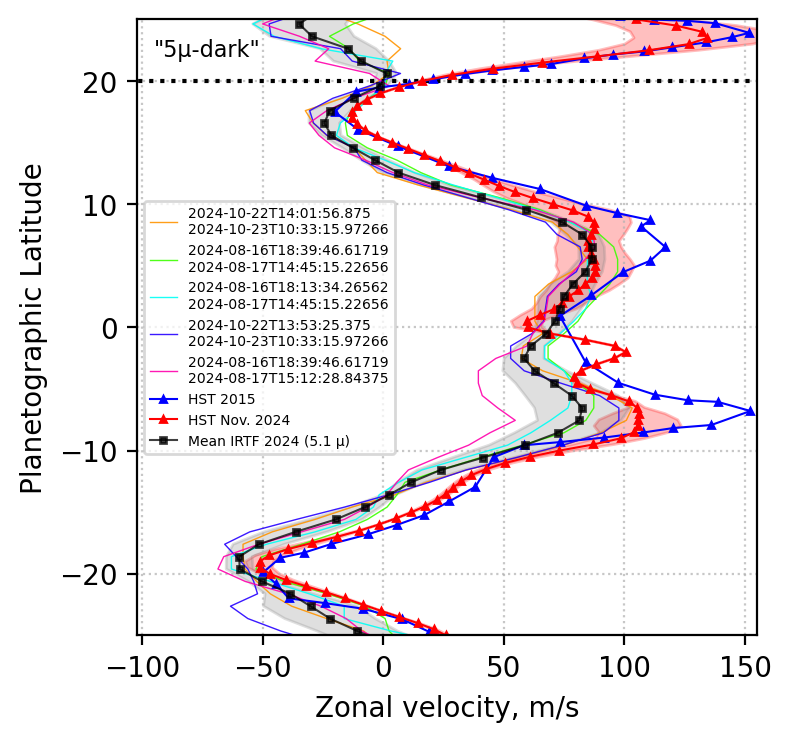

In [17]:
y_lim_range = 25

%matplotlib inline

plt.figure(figsize=(4,4), dpi=200)
plt.hlines(20, -120, 200, color='k', ls=':')
plt.text(-95, 22, '"5µ-dark"', fontsize=8)
for i in range(corr1D_array_smoothed.shape[0]):
# for i in [2]:
    plt.plot(corr1D_array_smoothed[i], lat_array, color=c_arr[i], lw=0.5, alpha=0.9, label=date_list[i][0]+'\n'+date_list[i][1])
plt.plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', marker='^', ms=2, lw=0.75, label='HST 2015')
plt.plot(opal_nov_2024_df['FMZW'][::5], opal_nov_2024_df['LAT'][::5], color='r', marker='^', ms=2, lw=0.75, label='HST Nov. 2024')
plt.fill_betweenx(opal_nov_2024_df['LAT'][::5], opal_nov_2024_df['FMZW'][::5]-opal_nov_2024_error_mag[::5], opal_nov_2024_df['FMZW'][::5]+opal_nov_2024_error_mag[::5], color='red', alpha=0.25)
plt.plot(mean_2024_ZWP, lat_array, color='k', marker='s', ms=2, lw=0.75, alpha=0.75, label='Mean IRTF 2024 (5.1 µ)')
plt.fill_betweenx(lat_array, mean_2024_ZWP-std_2024_ZWP, mean_2024_ZWP+std_2024_ZWP, color='gray', alpha=0.25)
plt.ylim(-y_lim_range, y_lim_range)
plt.xlim(-102, 155)
plt.grid(True, 'both', ls=':', alpha=0.7)
# plt.legend(bbox_to_anchor=(1.8, 1), loc='upper right', framealpha=0.75, fontsize='7')
plt.legend(loc='center left', framealpha=0.75, fontsize='5')
plt.xlabel('Zonal velocity, m/s'), plt.ylabel('Planetographic Latitude')
# plt.tight_layout()
plt.show()